# Final Project

## Question: How... ?

In [2]:
import mesa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from collections import deque

import networkx as nx

# Simulating a simple agent

Each agent has the following attributes:
* age_group: GenZ, Millenial, Boomer. Different age groups behave differently on the Internet.
* english_proficiency: Between 1 and 3. 1: Low, 2: Medium, 3: High. Describes how well the user speaks and understands English.
* topic: Gaming, Tech, Fashion, Nature. The preferred topic of the user.
* platforms: Instagram, TikTok, Reddit. The list of platforms used. A user can have one platform or use multiple platforms (cross-platform)

In [3]:
age_groups: list[str] = ["GenZ", "Millenial", "Boomer"]
topics: list[str] = ["Gaming", "Tech", "Fashion", "Nature"]
platforms: list[str] = ["Instagram", "TikTok", "Reddit"]

In [4]:
class PlayerAgent(mesa.Agent):
    def __init__(self, model:mesa.Model):
        super().__init__(model)

        self.age_group: int = self.get_random_age_group()
        self.english_proficiency: int = self.get_random_english_proficiency()
        self.main_topic: str = self.get_random_main_topic()
        self.platforms: list[str] = self.get_random_platforms()

        self.adopted = False # Whether the user adopted the english word or not

    def get_random_age_group(self) -> int:
        return random.choice(age_groups)

    def get_random_english_proficiency(self) -> int:
        return random.randint(1, 3)

    def get_random_main_topic(self) -> str:
        return random.choice(topics)

    def get_random_platforms(self) -> list[str]:
        random_platforms: list[str] = []

        for platform in platforms:
            if random.random() < 0.33:
                random_platforms.append(platform)

        # If player still has no platform, force a random one
        if len(random_platforms) == 0:
            random_platforms.append(random.choice(platforms))
        
        return random_platforms

    def print_description(self):
        """Prints the descirption of the player"""
        print(f'Player {self.unique_id} :')
        print(f'Age Group : {self.age_group}')
        print(f'English proficiency : {self.english_proficiency}')
        print(f'Main topic : {self.main_topic}')
        print("Platforms : ", end="")
        for i in range(len(self.platforms)):
            if i != 0:
                print(", ", end="")
            print(self.platforms[i], end="")

In [5]:
class SimpleGame(mesa.Model):
    def __init__(self, players_count: int):
        super().__init__()

        self.players_count: int = players_count
        self.player: PlayerAgent = PlayerAgent(self)

In [6]:
game: SimpleGame = SimpleGame(10)
game.player.print_description()

Player 1 :
Age Group : GenZ
English proficiency : 3
Main topic : Tech
Platforms : TikTok

# Creating Networks of social media users

In [7]:
class Network(mesa.Model):
    def __init__(self, rounds_count: int, players_count: int, inital_adopters: int):
        super().__init__()

        self.network = nx.Graph()
        self.rounds_count: int = rounds_count
        self.players_count: int = players_count
        self.players: list[PlayerAgent] = []
        self.adopted_players : list[PlayerAgent] = []

        self.connect_crossplatform_threshold: float = 0.2
        self.initial_adopters_count: int = inital_adopters

        self.create_players()
        self.connect_cross_platform_users()
        self.pick_initial_adopters()

        self.datacollector = mesa.DataCollector(
            {"Adoption Rate" : self.adoption_rate}
        )

    def create_players(self):
        """Creates all player agents and connects them in a network of social media users."""
        for _ in range(self.players_count):
            new_player: PlayerAgent = PlayerAgent(self)
            self.players.append(new_player)
            self.network.add_node(new_player)

    def connect_cross_platform_users(self):
        """Tries to connect users between each other if they share common platforms."""
        for player1 in self.players:
            for player2 in self.players:
                if player1 == player2:
                    continue

                shared_platforms: set[str] = set(player1.platforms) & set(player2.platforms)

                if len(shared_platforms) > 0 and random.random() < self.connect_crossplatform_threshold:
                    self.network.add_edge(player1, player2)

    def pick_initial_adopters(self):
        """Pick a few inital adopters that already know English words. Behave as influencers to influence other users to also use their words."""
        initial_adopters: list[PlayerAgent] = random.sample(self.players, self.initial_adopters_count)
        for player in initial_adopters:
            player.adopted = True
            self.adopted_players.append(player)

    def play_game(self):
        for i in range(self.rounds_count):
            print(f'Round {i + 1} :')
            self.play_round()
            print(f'Got adoption rate: {self.adoption_rate() * 100} %')
            self.datacollector.collect(self)

    def play_round(self):
        new_adopted_players: list[PlayerAgent] = []

        for player in self.players:
            neighbors: list[PlayerAgent] = list(self.network.neighbors(player))

            # Count the number of adopted neighbors
            adopted_neighbors: int = 0
            for neighbor in neighbors:
                if neighbor.adopted:
                    adopted_neighbors += 1
            
            # Compute adoption probability based on agent properties
            adoption_probability: float = 0.05

            if len(neighbors) > 0:
                adopted_fraction: float = adopted_neighbors / len(neighbors)
                adoption_probability += 0.5 * adopted_fraction

            adoption_probability += 0.02 * player.english_proficiency
            
            if player.age_group == "GenZ":
                adoption_probability += 0.15
            elif player.age_group == "Millenial":
                adoption_probability += 0.05

            if adoption_probability >= 1:
                adoption_probability = 1
            
            if not player.adopted:
                if random.random() < adoption_probability:
                    print(f'Agent {player.unique_id} adopted the English word ! (P = {adoption_probability} %)')
                    new_adopted_players.append(player)
                else:
                    print(f'Agent {player.unique_id} did not adopt the english word ! (P = {adoption_probability} %)')

        for adopted_player in new_adopted_players:
            adopted_player.adopted = True
            self.adopted_players.append(adopted_player)
    
    def adoption_rate(self) -> float:
        """Function for data collection. Returns the proportion of adopted players in the network."""
        return len(self.adopted_players) / self.players_count

In [8]:
def plot_adoption_rate(data: pd.DataFrame):
    adoption_rate = data["Adoption Rate"]
    rounds = np.arange(1, len(adoption_rate) + 1)

    plt.plot(rounds, adoption_rate)
    plt.title("Evolution of adoption rate over rounds")
    plt.xlabel("Rounds")
    plt.ylabel("Adoption rate (%)")
    plt.grid(True, alpha=0.3)

    plt.show()

Round 1 :
Agent 1 did not adopt the english word ! (P = 0.26 %)
Agent 3 did not adopt the english word ! (P = 0.16 %)
Agent 4 did not adopt the english word ! (P = 0.11 %)
Agent 5 did not adopt the english word ! (P = 0.09 %)
Agent 6 did not adopt the english word ! (P = 0.07 %)
Agent 7 did not adopt the english word ! (P = 0.37 %)
Agent 9 did not adopt the english word ! (P = 0.385 %)
Agent 10 did not adopt the english word ! (P = 0.12000000000000001 %)
Got adoption rate: 20.0 %
Round 2 :
Agent 1 adopted the English word ! (P = 0.26 %)
Agent 3 did not adopt the english word ! (P = 0.16 %)
Agent 4 did not adopt the english word ! (P = 0.11 %)
Agent 5 did not adopt the english word ! (P = 0.09 %)
Agent 6 did not adopt the english word ! (P = 0.07 %)
Agent 7 did not adopt the english word ! (P = 0.37 %)
Agent 9 did not adopt the english word ! (P = 0.385 %)
Agent 10 did not adopt the english word ! (P = 0.12000000000000001 %)
Got adoption rate: 30.0 %
Round 3 :
Agent 3 did not adopt the 

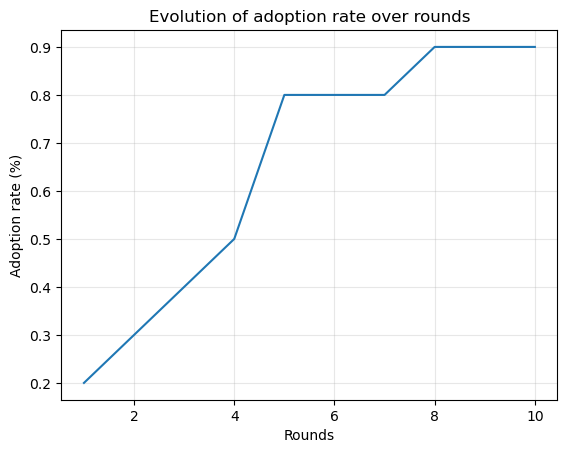

In [12]:
network = Network(rounds_count=10, players_count=10, inital_adopters=2)
network.play_game()

data = network.datacollector.get_model_vars_dataframe()
plot_adoption_rate(data)

# Advanced Network Topology & Diffusion Extension
1. Implemented Network Models
  * Scale-Free (Barabási-Albert) Model: Simulates the Influencer Effect. The network structure naturally forms a few highly connected "hubs"            (influencers) and many low-degree nodes (followers).
   * Small-World (Watts-Strogatz) Model: Simulates Topic Communities. Nodes form dense local clusters (e.g., tight-knit gaming or fashion interest bubbles) connected globally by rare long-range links (cross-platform users).
2. Enhanced Spreading Dynamics (play_round)The adoption mechanism updates synchronously each round based on a hybrid Independent Cascade and Linear Threshold framework. An uninfected user’s probability ($P$) of adopting an English word is calculated as:$$P_{\text{adoption}} = P_{\text{baseline}} + P_{\text{network}} + P_{\text{proficiency}} + P_{\text{demographic}}$$$P_{\text{baseline}}$ (0.03): Fixed background chance of picking up an anglicism via global internet trend exposure.$P_{\text{network}}$ ($0.55 \times \text{adopted\_fraction}$): Local network pressure. Measures the fraction of a node's active neighbors who have already adopted the word.$P_{\text{proficiency}}$ ($0.03 \times \text{proficiency\_level}$): Individual linguistic friction. Higher English competence lowers the barrier to entry.$P_{\text{demographic}}$ (+0.18 for GenZ, +0.06 for Millennials): Sociolinguistic bias accounting for younger generations being more receptive to code-switching.
3. Analytical GoalsBy running identical agent populations across different topologies, this setup isolates and evaluates how graph layout impacts linguistic spread—specifically comparing rapid vertical spikes caused by influencer hubs (Scale-Free) versus slower, localized saturation inside digital bubbles (Small-World).

In [10]:
class AdvancedNetwork(mesa.Model):
    def __init__(self, rounds_count: int, players_count: int, initial_adopters: int, network_type="scale_free"):
        super().__init__()
        
        self.rounds_count: int = rounds_count
        self.players_count: int = players_count
        self.players: list[PlayerAgent] = []
        self.adopted_players: list[PlayerAgent] = []
        self.initial_adopters_count: int = initial_adopters
        
        # 1. Dynamically initialize different structural network topologies
        if network_type == "scale_free":
            # Barabási-Albert model: Creates a few high-degree "Influencer Hubs"
            self.network = nx.barabasi_albert_graph(n=players_count, m=2)
        elif network_type == "small_world":
            # Watts-Strogatz model: High local clustering (niche interest bubbles)
            self.network = nx.watts_strogatz_graph(n=players_count, k=4, p=0.1)
        else:
            # Fallback to a basic random graph structure
            self.network = nx.erdos_renyi_graph(n=players_count, p=0.05)
            
        # 2. Instantiate PlayerAgents
        for _ in range(self.players_count):
            new_player = PlayerAgent(self)
            self.players.append(new_player)
            
        # 3. Relabel networkx graph node integers to map directly onto our PlayerAgent objects
        mapping = {i: self.players[i] for i in range(players_count)}
        self.network = nx.relabel_nodes(self.network, mapping)
        
        # 4. Set up baseline features from the original work
        self.pick_initial_adopters()
        
        self.datacollector = mesa.DataCollector(
            {"Adoption Rate" : self.adoption_rate}
        )
        
    def pick_initial_adopters(self):
        initial_adopters = random.sample(self.players, self.initial_adopters_count)
        for player in initial_adopters:
            player.adopted = True
            self.adopted_players.append(player)

    def play_game(self):
        for i in range(self.rounds_count):
            self.play_round()
            self.datacollector.collect(self)
            
    def play_round(self):
        """
        Calculates adoption over an Independent Cascade & Linear Threshold hybrid framework.
        """
        new_adopted_players = []

        for player in self.players:
            if player.adopted:
                continue
                
            neighbors = list(self.network.neighbors(player))
            adopted_neighbors = sum(1 for n in neighbors if n.adopted)
            
            # Base probability to adopt from general internet trend awareness
            adoption_probability = 0.03

            # Calculate network local pressure (Independent Cascade fraction)
            if len(neighbors) > 0:
                adopted_fraction = adopted_neighbors / len(neighbors)
                adoption_probability += 0.55 * adopted_fraction

            # Integrate original features (English proficiency & demographic boosts)
            adoption_probability += 0.03 * player.english_proficiency
            
            if player.age_group == "GenZ":
                adoption_probability += 0.18
            elif player.age_group == "Millenial":
                adoption_probability += 0.06

            # Bound probability parameters
            if adoption_probability >= 1.0:
                adoption_probability = 1.0
                
            # Random cascade threshold evaluation
            if random.random() < adoption_probability:
                new_adopted_players.append(player)

        # Commit adoptions synchronously at the end of the round
        for adopted_player in new_adopted_players:
            adopted_player.adopted = True
            self.adopted_players.append(adopted_player)
            
    def adoption_rate(self) -> float:
        return len(self.adopted_players) / self.players_count

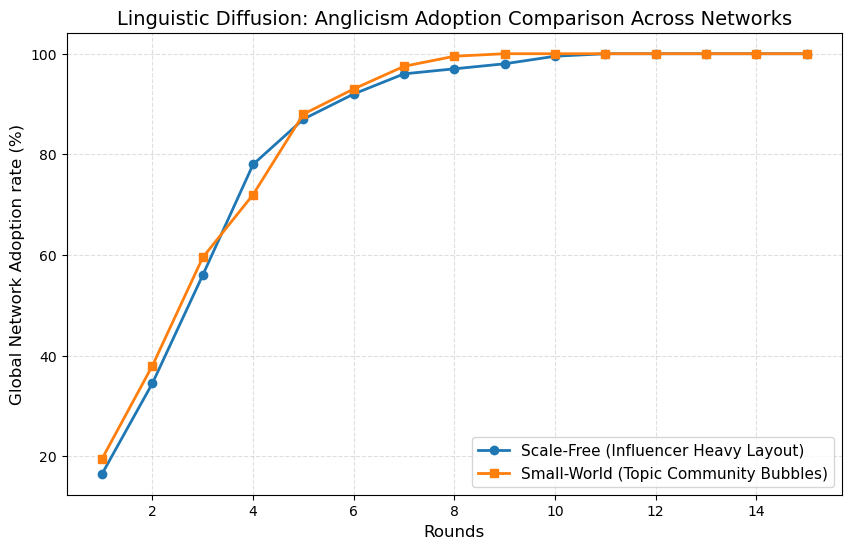

In [41]:
# Parameters for experiment validation
ROUNDS = 15
TOTAL_USERS = 200
INITIAL_SEED = 5

# Run Scale-Free (Influencer Network Layout)
scale_free_model = AdvancedNetwork(rounds_count=ROUNDS, players_count=TOTAL_USERS, initial_adopters=INITIAL_SEED, network_type="scale_free")
scale_free_model.play_game()
df_scale_free = scale_free_model.datacollector.get_model_vars_dataframe()

# Run Small-World (Clustered Communities Layout)
small_world_model = AdvancedNetwork(rounds_count=ROUNDS, players_count=TOTAL_USERS, initial_adopters=INITIAL_SEED, network_type="small_world")
small_world_model.play_game()
df_small_world = small_world_model.datacollector.get_model_vars_dataframe()

# Plotting the analytical results
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, ROUNDS + 1), df_scale_free["Adoption Rate"] * 100, label="Scale-Free (Influencer Heavy Layout)", marker='o', linewidth=2)
plt.plot(np.arange(1, ROUNDS + 1), df_small_world["Adoption Rate"] * 100, label="Small-World (Topic Community Bubbles)", marker='s', linewidth=2)

plt.title("Linguistic Diffusion: Anglicism Adoption Comparison Across Networks", fontsize=14)
plt.xlabel("Rounds", fontsize=12)
plt.ylabel("Global Network Adoption rate (%)", fontsize=12)
plt.grid(True, alpha=0.4, linestyle="--")
plt.legend(fontsize=11)
plt.show()

# Algorithmic Homophily /Filter bubble model
Unlike static network graphs, this notebook cell implements Dynamic Homophily. Social media recommendation engines constantly adjust our feeds to favor similar demographics. In Phase 2 of play_round(), agents check their connections. With a set rewiring probability, agents sever links with dissimilar age groups and replace them with peer links. This allows us to observe how algorithmic echo-chambers isolate language, causing high local clustering while stalling wide-scale global adoption outside generational silos."

In [21]:
class HomophilyNetwork(mesa.Model):
    def __init__(self, rounds_count: int, players_count: int, initial_adopters: int, rewiring_probability=0.2):
        super().__init__()
        
        self.rounds_count = rounds_count
        self.players_count = players_count
        self.rewiring_probability = rewiring_probability # Chance an agent alters an echo-chamber connection each round
        self.players = []
        self.adopted_players = []
        
        # Start with a standard random graph layout
        self.network = nx.erdos_renyi_graph(n=players_count, p=0.08)
        
        # Instantiate PlayerAgents (Assuming your colleague's original PlayerAgent exists)
        for _ in range(self.players_count):
            new_player = PlayerAgent(self)
            self.players.append(new_player)
            
        # Relabel graph integer nodes to map directly onto PlayerAgent objects
        mapping = {i: self.players[i] for i in range(players_count)}
        self.network = nx.relabel_nodes(self.network, mapping)
        
        # Set up seed adopters
        initial_seeds = random.sample(self.players, initial_adopters)
        for player in initial_seeds:
            player.adopted = True
            self.adopted_players.append(player)
            
        # track the adoption rate and the modularity/clustering over time
        self.datacollector = mesa.DataCollector({
            "Adoption Rate": self.adoption_rate,
            "Average Clustering": lambda m: nx.average_clustering(m.network)
        })
        
    def play_game(self):
        for i in range(self.rounds_count):
            self.play_round()
            self.datacollector.collect(self)
            
    def play_round(self):
        new_adopted_players = []
        
        # --- PHASE 1: STANDARD LINGUISTIC DIFFUSION ---
        for player in self.players:
            if player.adopted:
                continue
                
            neighbors = list(self.network.neighbors(player))
            adopted_neighbors = sum(1 for n in neighbors if n.adopted)
            
            # Combine peer presence with agent demographic rules
            adoption_probability = 0.03 # Base trend awareness
            if len(neighbors) > 0:
                adoption_probability += 0.55 * (adopted_neighbors / len(neighbors))
                
            adoption_probability += 0.03 * player.english_proficiency
            if player.age_group == "GenZ":
                adoption_probability += 0.18
            elif player.age_group == "Millenial":
                adoption_probability += 0.06
                
            if random.random() < min(adoption_probability, 1.0):
                new_adopted_players.append(player)
                
        # Commit adoptions synchronously
        for adopted_player in new_adopted_players:
            adopted_player.adopted = True
            self.adopted_players.append(adopted_player)
            
        # --- PHASE 2: ALGORITHMIC HOMOPHILY (NETWORK REWIRING) ---
        # Agents cut ties with people who are linguistically or generationally "dissimilar"
        for player in self.players:
            if random.random() > self.rewiring_probability:
                continue # Skip rewiring for this agent this round based on probability
                
            neighbors = list(self.network.neighbors(player))
            if not neighbors:
                continue
                
            # Find a neighbor with a different age group (dissimilar node)
            dissimilar_neighbors = [n for n in neighbors if n.age_group != player.age_group]
            
            if dissimilar_neighbors:
                bad_apple = random.choice(dissimilar_neighbors)
                
                # Find a candidate out in the network who shares the SAME age group
                candidates = [p for p in self.players if p != player and p not in neighbors and p.age_group == player.age_group]
                
                if candidates:
                    new_friend = random.choice(candidates)
                    
                    # Execute algorithmic shift: Unfriend the dissimilar, follow the similar
                    self.network.remove_edge(player, bad_apple)
                    self.network.add_edge(player, new_friend)
                    
    def adoption_rate(self) -> float:
        return len(self.adopted_players) / self.players_count

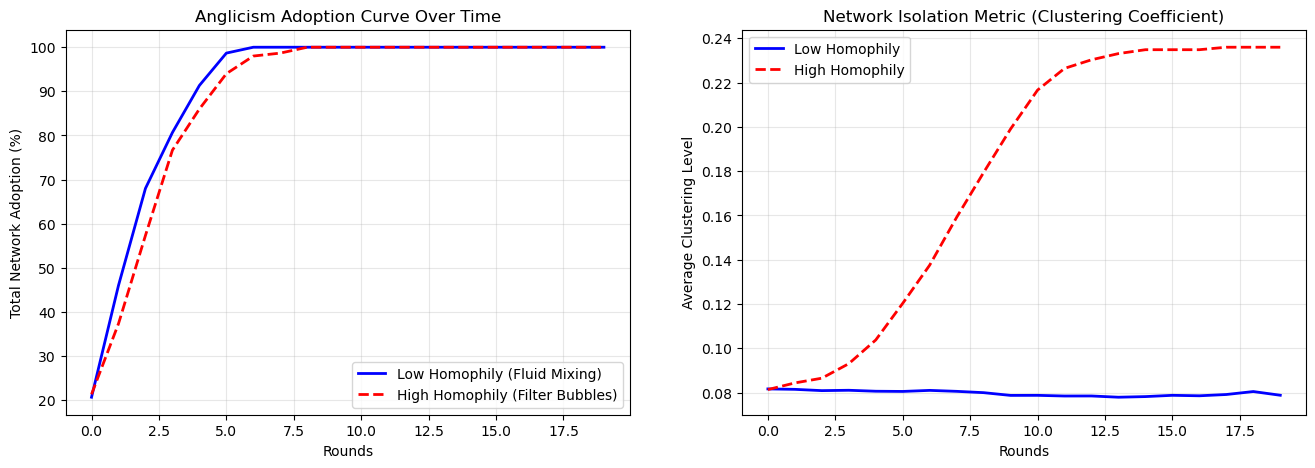

In [43]:
# Parameters for Homophily Stress Testing
ROUNDS = 20
TOTAL_USERS = 150
INITIAL_SEED = 5

# 1. Run Baseline Model (Low Rewiring - Dynamic Social Mixing)
low_homophily = HomophilyNetwork(ROUNDS, TOTAL_USERS, INITIAL_SEED, rewiring_probability=0.02)
low_homophily.play_game()
df_low = low_homophily.datacollector.get_model_vars_dataframe()

# 2. Run Filter Bubble Model (High Rewiring - Intense Algorithm Tuning)
high_homophily = HomophilyNetwork(ROUNDS, TOTAL_USERS, INITIAL_SEED, rewiring_probability=0.40)
high_homophily.play_game()
df_high = high_homophily.datacollector.get_model_vars_dataframe()

# 3. Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Global Word Adoption Curve
ax1.plot(df_low["Adoption Rate"] * 100, label="Low Homophily (Fluid Mixing)", color='blue', linewidth=2)
ax1.plot(df_high["Adoption Rate"] * 100, label="High Homophily (Filter Bubbles)", color='red', linestyle='--', linewidth=2)
ax1.set_title("Anglicism Adoption Curve Over Time")
ax1.set_xlabel("Rounds")
ax1.set_ylabel("Total Network Adoption (%)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Network Clustering Coefficient (Silo Growth Metric)
ax2.plot(df_low["Average Clustering"], label="Low Homophily", color='blue', linewidth=2)
ax2.plot(df_high["Average Clustering"], label="High Homophily", color='red', linestyle='--', linewidth=2)
ax2.set_title("Network Isolation Metric (Clustering Coefficient)")
ax2.set_xlabel("Rounds")
ax2.set_ylabel("Average Clustering Level")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.show()

# Evolutionary Mutation Model
Language on social media is rarely static. This model introduces Linguistic Drift (Evolutionary Mutation). When an agent influences their neighbor to adopt an anglicism, there is a configured mutation_rate representing morphological changes common in digital subcultures. Rather than observing a flat binary adoption rate, this tracking setup allows us to monitor biological-style generation waves, illustrating how secondary slang variants can completely overtake root word forms inside social clusters

In [28]:
class MutationNetwork(mesa.Model):
    def __init__(self, rounds_count: int, players_count: int, initial_adopters: int, mutation_rate=0.15):
        super().__init__()
        
        self.rounds_count = rounds_count
        self.players_count = players_count
        self.mutation_rate = mutation_rate  # Probability a word mutates when passed to a neighbor
        self.players = []
        
        # Word mutation dictionary tracking the evolutionary paths
        # Format: 'Current_Variant': 'Mutated_New_Variant'
        self.mutation_tree = {
            "cringe": "cringey",
            "cringey": "cringelings"
        }
        
        # Initialize a basic Small-World network layout for structural diffusion
        self.network = nx.watts_strogatz_graph(n=players_count, k=4, p=0.1)
        
        # Instantiate PlayerAgents (Assuming your colleague's original PlayerAgent exists)
        for _ in range(self.players_count):
            new_player = PlayerAgent(self)
            # EXTENSION: Add variant tracking directly to the agent runtime
            new_player.word_variant = None 
            self.players.append(new_player)
            
        # Relabel graph nodes to map directly onto PlayerAgent objects
        mapping = {i: self.players[i] for i in range(players_count)}
        self.network = nx.relabel_nodes(self.network, mapping)
        
        # Seed the network with the baseline target root word
        initial_seeds = random.sample(self.players, initial_adopters)
        for player in initial_seeds:
            player.adopted = True
            player.word_variant = "cringe"
            
        # Track the population count of each distinct linguistic variation over time
        self.datacollector = mesa.DataCollector({
            "Original (cringe)": lambda m: sum(1 for p in m.players if p.word_variant == "cringe"),
            "Mutation V1 (cringey)": lambda m: sum(1 for p in m.players if p.word_variant == "cringey"),
            "Mutation V2 (cringelings)": lambda m: sum(1 for p in m.players if p.word_variant == "cringelings"),
            "Uninfected": lambda m: sum(1 for p in m.players if p.word_variant is None)
        })
        
    def play_game(self):
        for i in range(self.rounds_count):
            self.play_round()
            self.datacollector.collect(self)
            
    def play_round(self):
        # Dictionary to store who adopts what specific variant this round
        new_adoptions = {} 
        
        for player in self.players:
            if player.adopted:
                continue
                
            neighbors = list(self.network.neighbors(player))
            adopted_neighbors = [n for n in neighbors if n.adopted and n.word_variant is not None]
            
            if not adopted_neighbors:
                continue
                
            # Count exposure to evaluate cascade probability
            adopted_fraction = len(adopted_neighbors) / len(neighbors)
            
            # Use original demographic rules for structural alignment
            adoption_probability = 0.03 + (0.55 * adopted_fraction) + (0.03 * player.english_proficiency)
            if player.age_group == "GenZ":
                adoption_probability += 0.18
            elif player.age_group == "Millenial":
                adoption_probability += 0.06
                
            if random.random() < min(adoption_probability, 1.0):
                # The agent adopts! Now determine WHICH variant they hear/adopt
                influencing_neighbor = random.choice(adopted_neighbors)
                heard_variant = influencing_neighbor.word_variant
                
                # Check for evolutionary mutation / linguistic drift
                if random.random() < self.mutation_rate and heard_variant in self.mutation_tree:
                    mutated_variant = self.mutation_tree[heard_variant]
                    new_adoptions[player] = mutated_variant
                else:
                    new_adoptions[player] = heard_variant
                    
        # Synchronously commit the structural language shift at the end of the step
        for player, variant in new_adoptions.items():
            player.adopted = True
            player.word_variant = variant

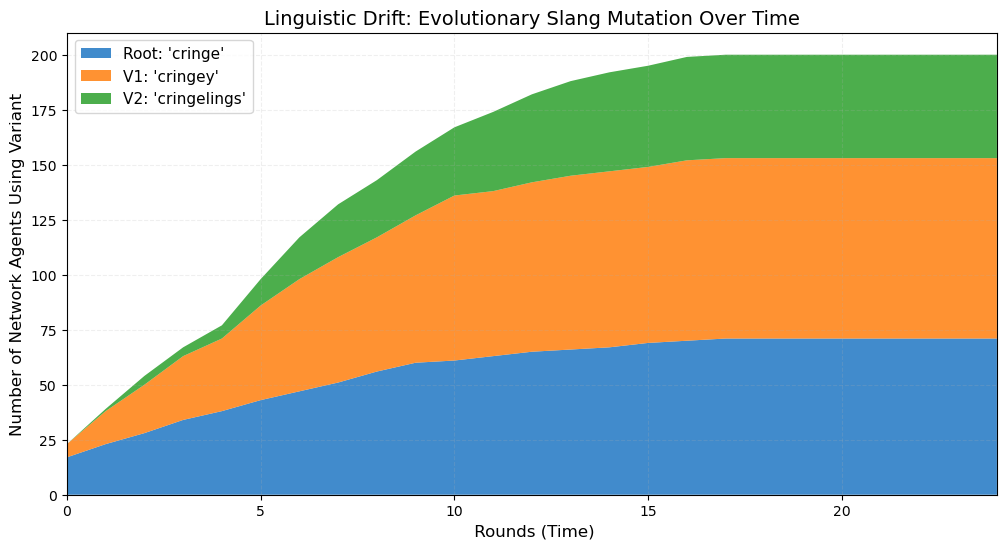

In [44]:
# Parameters for Linguistic Drift Experiment
ROUNDS = 25
TOTAL_USERS = 200
INITIAL_SEED = 8
MUTATION_RATE = 0.25 # 25% chance a word mutates when crossing into a new node

# Initialize and run the mutation model
mutation_model = MutationNetwork(ROUNDS, TOTAL_USERS, INITIAL_SEED, mutation_rate=MUTATION_RATE)
mutation_model.play_game()
df_evolution = mutation_model.datacollector.get_model_vars_dataframe()

# Plotting the Linguistic Evolution Stacked Chart
plt.figure(figsize=(12, 6))
plt.stackplot(
    df_evolution.index,
    df_evolution["Original (cringe)"],
    df_evolution["Mutation V1 (cringey)"],
    df_evolution["Mutation V2 (cringelings)"],
    labels=["Root: 'cringe'", "V1: 'cringey'", "V2: 'cringelings'"],
    colors=["#1f77c4", "#ff7f0e", "#2ca02c"],
    alpha=0.85
)

plt.title("Linguistic Drift: Evolutionary Slang Mutation Over Time", fontsize=14)
plt.xlabel(" Rounds (Time)", fontsize=12)
plt.ylabel("Number of Network Agents Using Variant", fontsize=12)
plt.xlim(0, ROUNDS-1)
plt.grid(True, alpha=0.2, linestyle="--")
plt.legend(loc="upper left", fontsize=11)
plt.show()

# Bicultural Idenetity and Agent Network Code
Linguistic adoption is not always binary. In social media posts, bilingual individuals selectively utilize anglicisms based on context and perceived audience identity. This model replaces standard flat tracking with Bicultural Identity Layers. Each agent is assigned an identity spectrum vector (global_identity_weight). When communicating across an edge, the sender agent checks the receiver's global index profile. If the audience profile signals a high local native alignment, the anglicism is suppressed and standard native syntax is used instead. This allows us to observe and map the computational divergence between general lexical knowledge and actual contextual code-switching performance.

In [39]:
class BiculturalNetwork(mesa.Model):
    def __init__(self, rounds_count: int, players_count: int, initial_adopters: int):
        super().__init__()
        
        self.rounds_count = rounds_count
        self.players_count = players_count
        self.players = []
        
        # Initialize a network layout mimicking heterogeneous community bridges
        self.network = nx.watts_strogatz_graph(n=players_count, k=5, p=0.15)
        
        # Instantiate PlayerAgents (Assuming your colleague's original PlayerAgent exists)
        for _ in range(self.players_count):
            new_player = PlayerAgent(self)
            
            # EXTENSION: Assign identity weight based heavily on demographic baseline
            if new_player.age_group == "GenZ":
                # High orientation toward global internet culture
                new_player.global_identity_weight = random.uniform(0.65, 0.95)
            elif new_player.age_group == "Millenial":
                # Balanced identity profile
                new_player.global_identity_weight = random.uniform(0.40, 0.70)
            else: # Boomer
                # Strong anchor in local native language structure
                new_player.global_identity_weight = random.uniform(0.05, 0.35)
                
            self.players.append(new_player)
            
        # Relabel graph node integers to map directly onto PlayerAgent objects
        mapping = {i: self.players[i] for i in range(players_count)}
        self.network = nx.relabel_nodes(self.network, mapping)
        
        # Seed initial awareness
        initial_seeds = random.sample(self.players, initial_adopters)
        for player in initial_seeds:
            player.adopted = True
            
        # Track active usage vs conversational suppression
        # FIXED: Wrapped in a lambda function context so Mesa validates correctly
        self.datacollector = mesa.DataCollector({
            "Awareness Rate (Internalized)": lambda m: sum(1 for p in m.players if p.adopted) / m.players_count,
            "Active Anglicism Usage (Code-Switching)": lambda m: m.calculate_active_usage()
        })
        
    def calculate_active_usage(self) -> float:
        """
        Calculates what percentage of total active connections are actively 
        exchanging the anglicism vs. suppressing it this round.
        """
        total_interactions = 0
        active_anglicism_posts = 0
        
        for u, v in self.network.edges():
            # Check edge interactions if at least one agent knows the word
            if u.adopted or v.adopted:
                total_interactions += 2
                
                # U talking to V: Contextual Code-Switching activation
                if u.adopted and random.random() < v.global_identity_weight:
                    active_anglicism_posts += 1
                    
                # V talking to U: Contextual Code-Switching activation
                if v.adopted and random.random() < u.global_identity_weight:
                    active_anglicism_posts += 1
                    
        return (active_anglicism_posts / total_interactions) if total_interactions > 0 else 0.0

    def play_game(self):
        for i in range(self.rounds_count):
            self.play_round()
            self.datacollector.collect(self)
            
    def play_round(self):
        new_adopters = []
        
        for player in self.players:
            if player.adopted:
                continue
                
            neighbors = list(self.network.neighbors(player))
            
            # Contextual exposure math: You only hear the word if your neighbor 
            # CHOOSES to use it when talking to you based on YOUR global identity score.
            active_exposures = 0
            for n in neighbors:
                if n.adopted and random.random() < player.global_identity_weight:
                    active_exposures += 1
                    
            if len(neighbors) > 0:
                adopted_fraction = active_exposures / len(neighbors)
                
                # Apply standard demographic variables for coherence
                adoption_probability = 0.03 + (0.55 * adopted_fraction) + (0.03 * player.english_proficiency)
                if player.age_group == "GenZ":
                    adoption_probability += 0.18
                elif player.age_group == "Millenial":
                    adoption_probability += 0.06
                    
                if random.random() < min(adoption_probability, 1.0):
                    new_adopters.append(player)
                    
        # Synchronous activation
        for player in new_adopters:
            player.adopted = True



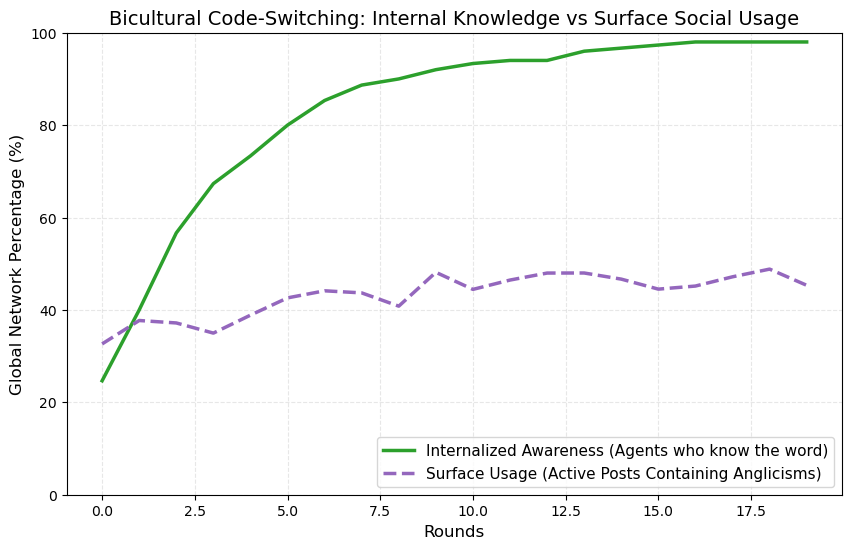

In [45]:
# --- EXECUTION AND PLOTTING BLOCK ---

# Parameters for Identity Modeling
ROUNDS = 20
TOTAL_USERS = 150
INITIAL_SEED = 10

# Initialize and run the framework
bicultural_model = BiculturalNetwork(ROUNDS, TOTAL_USERS, INITIAL_SEED)
bicultural_model.play_game()
df_identity = bicultural_model.datacollector.get_model_vars_dataframe()

# Plotting the Contrast Matrix
plt.figure(figsize=(10, 6))
plt.plot(df_identity["Awareness Rate (Internalized)"] * 100, label="Internalized Awareness (Agents who know the word)", color='#2ca02c', linewidth=2.5)
plt.plot(df_identity["Active Anglicism Usage (Code-Switching)"] * 100, label="Surface Usage (Active Posts Containing Anglicisms)", color='#9467bd', linestyle='--', linewidth=2.5)

plt.title("Bicultural Code-Switching: Internal Knowledge vs Surface Social Usage", fontsize=14)
plt.xlabel("Rounds", fontsize=12)
plt.ylabel("Global Network Percentage (%)", fontsize=12)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3, linestyle="--")
plt.legend(loc="lower right", fontsize=11)
plt.show()

# The Multi-Platform "Domain" Model (Code-Switching by App)
Prominent research on digital Anglicisms shows that multilingual speakers switch languages based on the domain (the platform environment). Influencers do not use the same density of English words on LinkedIn as they do on TikTok.
* TikTok/Instagram: Seen as informal, youth-dominated domains where English signifies modern identity.
* Facebook/LinkedIn: Seen as formal or family-oriented domains where standard native grammar rules are heavily enforced.

In [47]:
class MultiPlatformDomainNetwork(mesa.Model):
    def __init__(self, rounds_count: int, players_count: int, initial_adopters: int):
        super().__init__()
        
        self.rounds_count = rounds_count
        self.players_count = players_count
        self.players = []
        
        # Define platform domain shifts (Linguistic Domain Modifiers)
        # Positive values accelerate spread; negative values represent formal constraints that suppress it.
        self.domain_modifiers = {
            "TikTok": 0.25,      # High youth culture dominance
            "Instagram": 0.10,   # Curation and lifestyle focus
            "LinkedIn": -0.15    # Professional domain filtering (suppression)
        }
        
        # Start with a network layout mimicking heterogeneous community bridges
        self.network = nx.watts_strogatz_graph(n=players_count, k=5, p=0.15)
        
        # Instantiate PlayerAgents (Assuming your colleague's original PlayerAgent exists)
        for _ in range(self.players_count):
            new_player = PlayerAgent(self)
            
            # EXTENSION: Ensure agents have access to a pool of distinct platforms
            # If your colleague's script doesn't explicitly populate this, we safeguard it here:
            if not hasattr(new_player, 'platforms') or not new_player.platforms:
                new_player.platforms = random.sample(["Instagram", "TikTok", "LinkedIn"], k=random.randint(1, 3))
                
            self.players.append(new_player)
            
        # Relabel graph node integers to map directly onto PlayerAgent objects
        mapping = {i: self.players[i] for i in range(players_count)}
        self.network = nx.relabel_nodes(self.network, mapping)
        
        # Seed initial adopters
        initial_seeds = random.sample(self.players, initial_adopters)
        for player in initial_seeds:
            player.adopted = True
            
        # Track adoption rates sliced across platform ecosystems over time
        self.datacollector = mesa.DataCollector({
            "Global Adoption Rate": lambda m: sum(1 for p in m.players if p.adopted) / m.players_count,
            "TikTok Domain Activity": lambda m: m.calculate_platform_activity("TikTok"),
            "LinkedIn Domain Activity": lambda m: m.calculate_platform_activity("LinkedIn")
        })
        
    def calculate_platform_activity(self, platform_name: str) -> float:
        """
        Calculates the fraction of users on a specific platform who have adopted the word.
        """
        platform_users = [p for p in self.players if platform_name in p.platforms]
        if not platform_users:
            return 0.0
        adopted_platform_users = sum(1 for p in platform_users if p.adopted)
        return adopted_platform_users / len(platform_users)

    def play_game(self):
        for i in range(self.rounds_count):
            self.play_round()
            self.datacollector.collect(self)
            
    def play_round(self):
        new_adopters = []
        
        for player in self.players:
            if player.adopted:
                continue
                
            neighbors = list(self.network.neighbors(player))
            if not neighbors:
                continue
                
            # Filter neighbors to find who has adopted the word
            adopted_neighbors = [n for n in neighbors if n.adopted]
            
            if len(adopted_neighbors) > 0:
                # Select a random friend who is currently exposing the agent to the word
                influencer = random.choice(adopted_neighbors)
                
                # Find the overlapping platforms where this interaction could take place
                shared_platforms = list(set(player.platforms).intersection(set(influencer.platforms)))
                
                if not shared_platforms:
                    continue # No overlapping platform domain to pass the word
                    
                # Pick the active platform domain for this step's interaction
                active_domain = random.choice(shared_platforms)
                
                # Base math from your colleague's network setup
                adopted_fraction = len(adopted_neighbors) / len(neighbors)
                adoption_probability = 0.03 + (0.55 * adopted_fraction) + (0.03 * player.english_proficiency)
                
                # Apply demographic variables
                if player.age_group == "GenZ":
                    adoption_probability += 0.18
                elif player.age_group == "Millenial":
                    adoption_probability += 0.06
                    
                # EXTENSION: Inject the dynamic Domain Modifier based on the chosen platform
                adoption_probability += self.domain_modifiers.get(active_domain, 0.0)
                
                # Execute the bounded probability check
                if random.random() < min(max(adoption_probability, 0.0), 1.0):
                    new_adopters.append(player)
                    
        # Synchronous commit
        for player in new_adopters:
            player.adopted = True

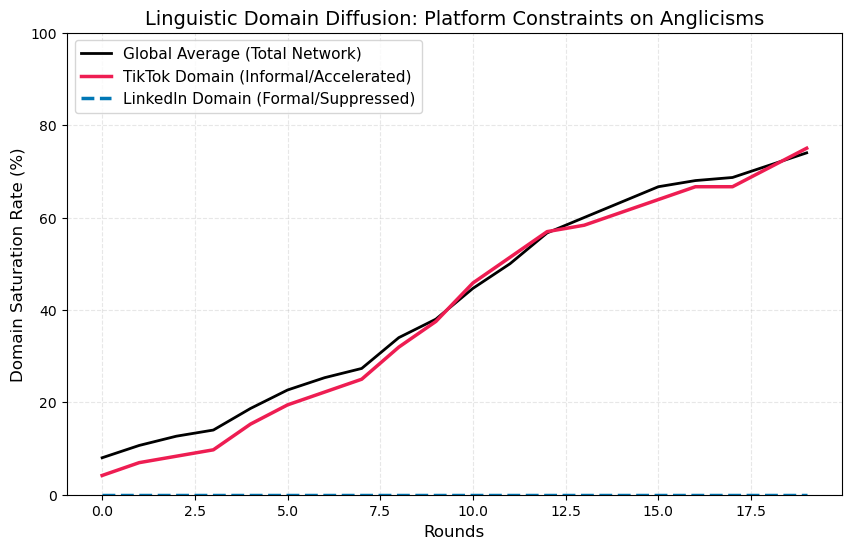

In [49]:
# Parameters for Multi-Platform Domain Analysis
ROUNDS = 20
TOTAL_USERS = 150
INITIAL_SEED = 8

# Initialize and execute the model
domain_model = MultiPlatformDomainNetwork(ROUNDS, TOTAL_USERS, INITIAL_SEED)
domain_model.play_game()
df_domains = domain_model.datacollector.get_model_vars_dataframe()

# Plotting the Analytical Results
plt.figure(figsize=(10, 6))
plt.plot(df_domains["Global Adoption Rate"] * 100, label="Global Average (Total Network)", color='black', linewidth=2)
plt.plot(df_domains["TikTok Domain Activity"] * 100, label="TikTok Domain (Informal/Accelerated)", color='#ee1d52', linestyle='-', linewidth=2.5)
plt.plot(df_domains["LinkedIn Domain Activity"] * 100, label="LinkedIn Domain (Formal/Suppressed)", color='#0077b5', linestyle='--', linewidth=2.5)

plt.title("Linguistic Domain Diffusion: Platform Constraints on Anglicisms", fontsize=14)
plt.xlabel("Rounds", fontsize=12)
plt.ylabel("Domain Saturation Rate (%)", fontsize=12)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3, linestyle="--")
plt.legend(loc="upper left", fontsize=11)
plt.show()